<div dir="rtl" style="text-align: right">

‏# 04 — بهینه‌سازی hyperparameter با Optuna

</div>

In [ ]:
# Persian text rendering for notebook markdown and plots
import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": [
        "Vazirmatn",
        "Vazir",
        "IRANSans",
        "Noto Sans Arabic",
        "Noto Naskh Arabic",
        "DejaVu Sans",
    ],
    "axes.unicode_minus": False,
})

try:
    from IPython.display import HTML, display

    display(HTML('<div dir="rtl" style="text-align: right"></div>'))
except Exception:
    pass

<div dir="rtl" style="text-align: right">

‏<style>
‏/* Improve RTL readability for notebook markdown in JupyterLab/classic */
‏.jp-RenderedMarkdown,
‏.rendered_html,
‏div.text_cell_render,
‏div.output_area,
‏.jp-MarkdownOutput {
‏  direction: rtl;
‏  text-align: right;
‏}

‏.jp-RenderedMarkdown table,
‏.rendered_html table,
‏div.text_cell_render table {
‏  direction: rtl;
‏  text-align: right;
‏}

‏.jp-RenderedMarkdown li,
‏.rendered_html li,
‏div.text_cell_render li {
‏  margin-right: 1.2em;
‏}
‏</style>

</div>

In [1]:
import hashlib, json, os, platform, random, warnings
from pathlib import Path
ROOT = Path.cwd()
if not (ROOT / "data").exists() and (ROOT.parent / "data").exists():
    ROOT = ROOT.parent
# هشدارهای سازگاری/رابط کاربری روی پیش‌بینی‌ها یا اجرای دفترچه اثر ندارند.
warnings.filterwarnings("ignore", message="X does not have valid feature names, but LGBMClassifier")
warnings.filterwarnings("ignore", message="IProgress not found.*")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (average_precision_score, confusion_matrix, log_loss,
                             precision_score, recall_score)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

SEED = 42
TARGET = "y"
LEAKAGE_COLUMNS = ["duration"]

def project_root():
    # اگر ریشه دوره در دسترس بود همان را برگردان، وگرنه پوشه دفترچه را.
    return ROOT

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)

def fast_mode():
    # برای آزمایش‌های کامل، FAST_MODE=0 را تنظیم کنید؛ حالت لپ‌تاپ به‌صورت پیش‌فرض فعال است.
    return os.getenv("FAST_MODE", "1").lower() not in {"0", "false", "no"}

def bank_data_path():
    # این دوره با یک مجموعه‌داده محلی همراه است؛ دفترچه‌ها هرگز به شبکه دسترسی ندارند.
    path = project_root() / "data" / "raw" / "bank-full.csv"
    if not path.is_file():
        raise FileNotFoundError(
            f"Expected the bundled Bank Marketing data at {path}. "
            "Run the notebook from the course root or place bank-full.csv there."
        )
    return path

def file_sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(1 << 20), b""):
            digest.update(chunk)
    return digest.hexdigest()

def load_bank_data(include_duration=False):
    # داده را بارگذاری کن، y را encode کن، و مدت تماس پس از تماس را به‌صورت پیش‌فرض حذف کن.
    frame = pd.read_csv(bank_data_path(), sep=";")
    frame[TARGET] = frame[TARGET].map({"no": 0, "yes": 1}).astype("int8")
    if not include_duration:
        frame = frame.drop(columns=LEAKAGE_COLUMNS)
    return frame

def stratified_sample(frame, n, seed=SEED):
    if n >= len(frame):
        return frame.copy()
    fractions = frame[TARGET].value_counts(normalize=True)
    counts = (fractions * n).round().astype(int)
    counts.iloc[0] += n - counts.sum()
    parts = [group.sample(n=min(counts.loc[label], len(group)),
                          random_state=seed + int(label))
             for label, group in frame.groupby(TARGET)]
    return pd.concat(parts).sample(frac=1, random_state=seed).reset_index(drop=True)

def make_splits(frame=None, reduced=None):
    # split قطعی و stratified به نسبت 60/20/20؛ مجموعه آزمون تا دفترچه 09 قفل می‌ماند.
    from sklearn.model_selection import train_test_split
    frame = load_bank_data() if frame is None else frame
    train_val, test = train_test_split(
        frame, test_size=0.20, stratify=frame[TARGET], random_state=SEED)
    train, validation = train_test_split(
        train_val, test_size=0.25, stratify=train_val[TARGET], random_state=SEED)
    reduced = fast_mode() if reduced is None else reduced
    if reduced:
        train = stratified_sample(train, 12_000)
        validation = stratified_sample(validation, 4_000, SEED + 1)
        test = stratified_sample(test, 4_000, SEED + 2)
    return tuple(part.reset_index(drop=True) for part in (train, validation, test))

def split_xy(frame):
    return frame.drop(columns=TARGET), frame[TARGET]

def feature_groups(frame):
    features = frame.drop(columns=[TARGET], errors="ignore")
    categorical = features.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
    numerical = features.select_dtypes(include=np.number).columns.tolist()
    return numerical, categorical

def make_preprocessor(frame, scale_numeric=True):
    # preprocessing فقط داخل pipeline آموزش/CV مربوطه fit می‌شود.
    numerical, categorical = feature_groups(frame)
    numeric_steps = [("impute", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scale", StandardScaler()))
    categorical_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="infrequent_if_exist",
                                 min_frequency=10, sparse_output=True)),
    ])
    return ColumnTransformer([
        ("numeric", Pipeline(numeric_steps), numerical),
        ("categorical", categorical_pipe, categorical),
    ], sparse_threshold=0.3)

def classification_metrics(y_true, probability, threshold=0.5):
    prediction = np.asarray(probability) >= threshold
    tn, fp, fn, tp = confusion_matrix(y_true, prediction, labels=[0, 1]).ravel()
    return {"average_precision": average_precision_score(y_true, probability),
            "log_loss": log_loss(y_true, probability),
            "precision": precision_score(y_true, prediction, zero_division=0),
            "recall": recall_score(y_true, prediction, zero_division=0),
            "specificity": tn / (tn + fp) if (tn + fp) else np.nan,
            "cost": float(fp + 5 * fn)}

def threshold_table(y_true, probability, thresholds=None):
    thresholds = np.linspace(0.05, 0.80, 76) if thresholds is None else thresholds
    return pd.DataFrame([{"threshold": float(t),
                          **classification_metrics(y_true, probability, float(t))}
                         for t in thresholds])

def add_domain_features(frame):
    result = frame.copy()
    result["was_previously_contacted"] = (result["pdays"] != -1).astype("int8")
    result["pdays_clean"] = result["pdays"].replace(-1, np.nan)
    result["contact_pressure"] = result["campaign"] / (1 + result["previous"])
    result["balance_per_age"] = result["balance"] / result["age"].clip(lower=18)
    result["age_band"] = pd.cut(result["age"], bins=[0, 29, 39, 49, 59, np.inf],
                                labels=["<30", "30s", "40s", "50s", "60+"]).astype("object")
    return result.drop(columns=["pdays"])

def environment_metadata():
    import sklearn
    return {"python": platform.python_version(), "platform": platform.platform(),
            "numpy": np.__version__, "pandas": pd.__version__,
            "scikit_learn": sklearn.__version__}

def write_json(data, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(data, indent=2, sort_keys=True), encoding="utf-8")

set_seed(SEED)
FAST_MODE = fast_mode()
CV_FOLDS = 3 if FAST_MODE else 5
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 30)
print({"FAST_MODE": FAST_MODE, "CV_FOLDS": CV_FOLDS, "seed": SEED})

{'FAST_MODE': True, 'CV_FOLDS': 3, 'seed': 42}


In [2]:
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score

development, validation, _sealed_test = make_splits(load_bank_data(), reduced=FAST_MODE)
X_dev, y_dev = split_xy(development)
X_val, y_val = split_xy(validation)
print("Library versions:", lgb.__version__)

Library versions: 4.6.0


<div dir="rtl" style="text-align: right">

‏## طراحی study در Optuna

</div>

In [3]:
# یک baseline بدون تنظیم به Optuna یک هدف منصفانه برای شکست‌دادن می‌دهد.
preprocessor = make_preprocessor(development, scale_numeric=False)
X_dev_encoded = preprocessor.fit_transform(X_dev, y_dev)
X_val_encoded = preprocessor.transform(X_val)

lightgbm_baseline = lgb.LGBMClassifier(
    objective="binary", n_estimators=1000, learning_rate=0.04,
    num_leaves=31, min_child_samples=30, subsample=0.9,
    colsample_bytree=0.9, reg_lambda=1.0, random_state=SEED,
    n_jobs=-1, verbosity=-1,
)
lightgbm_baseline.fit(
    X_dev_encoded, y_dev, eval_set=[(X_val_encoded, y_val)],
    eval_metric="average_precision",
    callbacks=[lgb.early_stopping(50, verbose=False)],
)
lgb_p = lightgbm_baseline.predict_proba(X_val_encoded)[:, 1]
print("LightGBM best iteration:", lightgbm_baseline.best_iteration_)
pd.Series(classification_metrics(y_val, lgb_p), name="untuned LightGBM")

LightGBM best iteration: 103


average_precision 0.451216
log_loss          0.283930
precision         0.662069
recall            0.205128
specificity       0.986127
cost           1909.000000
Name: untuned LightGBM, dtype: float64

<div dir="rtl" style="text-align: right">

‏## Design the Optuna study

‏The objective below uses only development folds. Each fold fits its own encoder and uses its
‏validation fold for early stopping. The trial reports intermediate mean average precision after each fold,
‏enabling Optuna's median pruner. The sealed test set is absent from the function, and the
‏validation set is also absent from the objective.

‏`FAST_MODE=1` runs 8 trials × 3 folds; full mode runs 25 × 5. This is an educational search,
‏not evidence that 25 trials fully explores the space.

‏### Search-space choices

‏| Parameter | Why Optuna tunes it | Bound used here |
‏|---|---|---|
‏| `learning_rate` | shrinkage/iteration tradeoff | log scale, 0.02–0.12 |
‏| `num_leaves` | tree complexity | 15–63 |
‏| `min_child_samples` | leaf regularization | 20–100 |
‏| `subsample` | row sampling regularization | 0.70–1.00 |
‏| `colsample_bytree` | feature sampling regularization | 0.70–1.00 |
‏| `reg_alpha`, `reg_lambda` | L1/L2 regularization | log-scaled positive ranges |

</div>

In [4]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)

def objective(trial):
    # میانگین precision اعتبارسنجیِ cross-validated فقط روی داده توسعه را برای یک trial برگردان.
    params = {
        "objective": "binary", "verbosity": -1, "n_jobs": -1,
        "random_state": SEED, "n_estimators": 800,
        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.12, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 15, 63),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 100),
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 2.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 5.0, log=True),
    }
    fold_scores = []
    for fold, (fit_idx, stop_idx) in enumerate(cv.split(X_dev, y_dev)):
        X_fit, X_stop = X_dev.iloc[fit_idx], X_dev.iloc[stop_idx]
        y_fit, y_stop = y_dev.iloc[fit_idx], y_dev.iloc[stop_idx]
        fold_pre = make_preprocessor(development.iloc[fit_idx], scale_numeric=False)
        X_fit_e = fold_pre.fit_transform(X_fit, y_fit)
        X_stop_e = fold_pre.transform(X_stop)
        model = lgb.LGBMClassifier(**params)
        model.fit(X_fit_e, y_fit, eval_set=[(X_stop_e, y_stop)],
                  eval_metric="average_precision",
                  callbacks=[lgb.early_stopping(35, verbose=False)])
        fold_scores.append(average_precision_score(y_stop, model.predict_proba(X_stop_e)[:, 1]))
        trial.report(float(np.mean(fold_scores)), step=fold)
        if trial.should_prune():
            raise optuna.trialPruned()
    return float(np.mean(fold_scores))

study = optuna.create_study(
    direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=3),
)
study.optimize(objective, n_trials=8 if FAST_MODE else 25, timeout=180 if FAST_MODE else 900)
print("best CV average precision:", round(study.best_value, 4))
display(pd.Series(study.best_params, name="best parameter"))

best CV average precision: 0.4067


learning_rate         0.057812
num_leaves           17.000000
min_child_samples    69.000000
subsample             0.751157
colsample_bytree      0.719515
reg_alpha             1.205550
reg_lambda            3.731160
Name: best parameter, dtype: float64

,number,value,state,params_colsample_bytree,params_learning_rate,params_min_child_samples,params_num_leaves,params_reg_alpha,params_reg_lambda,params_subsample,duration
4,4,0.406731,COMPLETE,0.719515,0.057812,69,17,1.205550,3.731160,0.751157,0 days 00:00:01.235341
6,6,0.403964,PRUNED,0.793513,0.021271,40,59,0.017252,0.105260,0.898757,0 days 00:00:01.115047
2,2,0.403551,COMPLETE,0.829584,0.027702,44,23,0.001789,0.183327,0.857427,0 days 00:00:01.795991
7,7,0.403444,PRUNED,0.968448,0.027853,82,62,0.037289,2.570308,0.981850,0 days 00:00:01.668115
5,5,0.402733,COMPLETE,0.832046,0.085131,27,29,0.000335,0.067865,0.905270,0 days 00:00:01.137909
1,1,0.399314,COMPLETE,0.990973,0.094416,77,44,0.380505,0.006101,0.706175,0 days 00:00:01.357113
3,3,0.395316,PRUNED,0.935553,0.025679,49,29,0.000722,0.079825,0.836821,0 days 00:00:00.564384
0,0,0.395213,COMPLETE,0.746806,0.039127,79,61,0.000469,0.001640,0.879598,0 days 00:00:02.232833


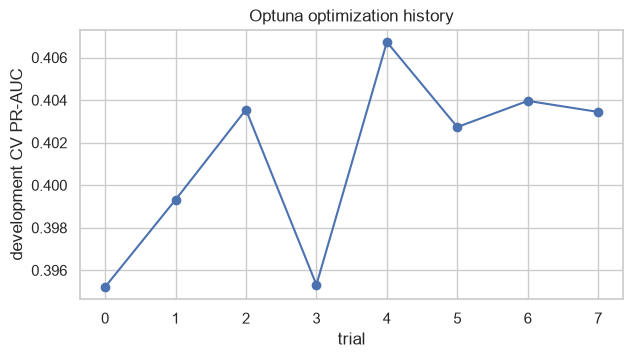

In [5]:
trials = study.trials_dataframe(attrs=("number", "value", "state", "params", "duration"))
trials = trials.sort_values("value", ascending=False, na_position="last")
display(trials.head(10))

ax = study.trials_dataframe(attrs=("number", "value")).plot(
    x="number", y="value", marker="o", legend=False, figsize=(7, 3.5)
)
ax.set_title("تاریخچه بهینه‌سازی Optuna")
ax.set_xlabel("trial")
ax.set_ylabel("development CV average precision")
plt.show()

,parameter,importance
0,num_leaves,0.231316
1,subsample,0.218537
2,min_child_samples,0.186837
3,learning_rate,0.138984
4,colsample_bytree,0.118515
5,reg_lambda,0.090131
6,reg_alpha,0.015681


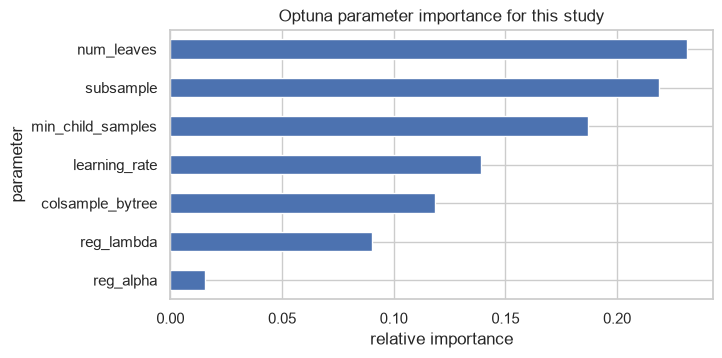

In [6]:
try:
    importances = optuna.importance.get_param_importances(study)
    importance_frame = (
        pd.Series(importances, name="importance")
        .rename_axis("parameter")
        .reset_index()
        .sort_values("importance", ascending=True)
    )
    display(importance_frame.sort_values("importance", ascending=False))
    importance_frame.plot.barh(x="parameter", y="importance", legend=False, figsize=(7, 3.5))
    plt.title("Optuna parameter importance for this study")
    plt.xlabel("relative importance")
    plt.show()
except Exception as exc:
    print(f"Parameter importance skipped: {exc}")

In [7]:
tuned_params = {
    **study.best_params, "objective": "binary", "verbosity": -1,
    "n_jobs": -1, "random_state": SEED, "n_estimators": 1200,
}
tuned = lgb.LGBMClassifier(**tuned_params)
tuned.fit(X_dev_encoded, y_dev, eval_set=[(X_val_encoded, y_val)],
          eval_metric="average_precision",
          callbacks=[lgb.early_stopping(50, verbose=False)])
tuned_p = tuned.predict_proba(X_val_encoded)[:, 1]
validation_comparison = pd.DataFrame({
    "untuned LightGBM": classification_metrics(y_val, lgb_p),
    "Optuna LightGBM": classification_metrics(y_val, tuned_p),
}).T
validation_comparison

average_precision  log_loss  precision    recall  \
untuned LightGBM  0.80244  0.451216  0.283930   0.662069  0.205128   
Optuna LightGBM   0.80089  0.450645  0.284608   0.664557  0.224359   

                  specificity    cost  
untuned LightGBM     0.986127  1909.0  
Optuna LightGBM      0.984994  1868.0

<div dir="rtl" style="text-align: right">

‏A tiny validation gain may not survive sampling variation and may not justify added search cost.
‏Trial histories are adaptive; the best CV score is optimistically selected. Final claims wait for
‏notebook 09's one-time test evaluation.

‏## Common mistakes and leakage warnings

‏- Optimizing Optuna against validation repeatedly or against test even once.
‏- Fitting one encoder before CV and reusing it across folds.
‏- Letting early stopping inspect the same rows used to fit trees.
‏- Searching huge spaces with too few trials, then overinterpreting the winner.
‏- Treating parameter importance as universal truth instead of study-specific diagnostics.
‏- Retuning the search space after looking at validation until the validation result improves.

‏## Exercises

‏1. Plot Optuna parameter importance and explain why it is study-specific.
‏2. Add a time budget and compare the best-so-far curve across two seeded studies.
‏3. Add `scale_pos_weight` to the search space and explain how it changes threshold behavior.
‏4. **Challenge:** implement nested CV for unbiased tuning-performance estimation and state its
‏   computational cost.

‏## Summary

‏Optuna turns hyperparameter tuning into a reproducible study: define the objective, bound the
‏search space, prune weak trials, inspect diagnostics, and promote one candidate. The objective
‏stays inside the development boundary. Validation compares finalists, while test evaluation
‏remains deferred.

‏## References

‏- [Optuna first optimization](https://optuna.readthedocs.io/en/stable/tutorial/10_key_features/001_first.html)
‏- [Optuna efficient optimization](https://optuna.readthedocs.io/en/stable/tutorial/10_key_features/003_efficient_optimization_algorithms.html)
‏- [Optuna pruning](https://optuna.readthedocs.io/en/stable/tutorial/10_key_features/003_efficient_optimization_algorithms.html#pruning-algorithms)
‏- [LightGBM Python API](https://lightgbm.readthedocs.io/en/latest/Python-API.html)

</div>